<a href="https://colab.research.google.com/github/PinkOrangeSapphire/223351/blob/main/Relationships_Between_Self_Congruity_and_Social_Influence_on_Purchase_Decision_Making_of_Holistic_Wellness_Products_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

file_path = '/content/แบบสอบถาม เรื่อง การตัดสินใจซื้อสินค้าหมวดหมู่การดูแลสุขภาพแบบองค์รวม (1-152).xlsx'
df = pd.read_excel(file_path)

# Display the first 5 rows of the DataFrame
print(df.head())

   ID          Start time     Completion time                           Email  \
0   1 2026-02-26 11:25:45 2026-02-26 11:34:33     tanyaporn_kabkaew@cmu.ac.th   
1   2 2026-02-26 11:39:06 2026-02-26 11:43:12      tanatchapon_than@cmu.ac.th   
2   3 2026-02-26 11:47:40 2026-02-26 11:54:04              tevika_s@cmu.ac.th   
3   4 2026-02-26 11:51:12 2026-02-26 11:54:24  kanyavee_winyaratana@cmu.ac.th   
4   5 2026-02-26 11:55:58 2026-02-26 12:01:09           chalisa_son@cmu.ac.th   

                    Name  Last modified time  \
0      TANYAPORN KABKAEW                 NaN   
1  TANATCHAPON THANAMORK                 NaN   
2        TEVIKA SURIYASA                 NaN   
3   KANYAVEE WINYARATANA                 NaN   
4      CHALISA SONSUPHAP                 NaN   

  คุณเป็นนักศึกษาคณะมนุษยศาสตร์ มหาวิทยาลัยเชียงใหม่  \
0                                                ใช่   
1                                                ใช่   
2                                                ใช่   


In [6]:
!pip install pingouin
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import pingouin as pg
import scipy.stats as stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [7]:
gender_freq = df['เพศ'].value_counts().dropna()
gender_freq


,count
เพศ,
หญิง,97
ชาย,27
LGBTQ+,19
ไม่ต้องการระบุ,8


In [8]:
age_freq = df['อายุ'].value_counts().dropna()
age_freq

,count
อายุ,
18 - 20 ปี,96
21 - 23 ปี,55


In [9]:
year_freq = df['ชั้นปี'].value_counts().dropna()
year_freq

,count
ชั้นปี,
ชั้นปีที่ 2,57
ชั้นปีที่ 3,51
ชั้นปีที่ 1,38
ชั้นปีที่ 4,5


In [10]:
gender_percent = df['เพศ'].value_counts(normalize=True)*100
gender_percent

,proportion
เพศ,
หญิง,64.238411
ชาย,17.880795
LGBTQ+,12.582781
ไม่ต้องการระบุ,5.298013


In [11]:
age_percent = df['อายุ'].value_counts(normalize=True)*100
age_percent

,proportion
อายุ,
18 - 20 ปี,63.576159
21 - 23 ปี,36.423841


In [12]:
year_percent = df['ชั้นปี'].value_counts(normalize=True)*100
year_percent

,proportion
ชั้นปี,
ชั้นปีที่ 2,37.748344
ชั้นปีที่ 3,33.774834
ชั้นปีที่ 1,25.165563
ชั้นปีที่ 4,3.311258


In [13]:
gender_table = pd.DataFrame({

    'Frequency': df['เพศ'].value_counts(),

    'Percentage': df['เพศ'].value_counts(normalize=True)*100

})

gender_table

,Frequency,Percentage
เพศ,,
หญิง,97,64.238411
ชาย,27,17.880795
LGBTQ+,19,12.582781
ไม่ต้องการระบุ,8,5.298013


In [14]:
age_table = pd.DataFrame({

    'Frequency': df['อายุ'].value_counts(),

    'Percentage': df['อายุ'].value_counts(normalize=True)*100

})

age_table

,Frequency,Percentage
อายุ,,
18 - 20 ปี,96,63.576159
21 - 23 ปี,55,36.423841


In [15]:
year_table = pd.DataFrame({

    'Frequency': df['ชั้นปี'].value_counts(),

    'Percentage': df['ชั้นปี'].value_counts(normalize=True)*100

})

year_table

,Frequency,Percentage
ชั้นปี,,
ชั้นปีที่ 2,57,37.748344
ชั้นปีที่ 3,51,33.774834
ชั้นปีที่ 1,38,25.165563
ชั้นปีที่ 4,5,3.311258


In [16]:
gender_table['Percentage'] = gender_table['Percentage'].round(2)
age_table['Percentage'] = age_table['Percentage'].round(2)
year_table['Percentage'] = year_table['Percentage'].round(2)

In [17]:
drop_cols = ['ID','Start time','Completion time','Email','Name','Last modified time']

df = df.drop(columns=drop_cols, errors='ignore')

In [18]:
likert = df.drop(columns=['ชั้นปี'])
likert = df.iloc[:,5:]
likert.dropna()
likert.head()

,1. สินค้า Wellness สามารถส่งเสริม ความเป็นตัวคุณได้,2. สินค้า Wellness ช่วยยกระดับภาพลักษณ์คุณได้,3. สินค้า Wellness สร้างความมั่นใจให้ตัวคุณ,4. สินค้า Wellness บ่งบอกความเป็นตัวคุณได้,1. คุณปรึกษาคุณพ่อคุณแม่ของคุณก่อนซื้อสินค้า Wellness,2. คุณถามคุณพ่อคุณแม่ เมื่อคุณไม่แน่ใจว่าราคาของสินค้า Wellness นั้นถูกหรือแพงเกินไปที่จะซื้อหรือไม่,3. คุณกับคุณพ่อคุณแม่มักจะวางแผนด้วยกันก่อนจะซื้อสินค้า Wellness,4. คุณทำตามสิ่งที่คุณพ่อคุณแม่ตัดสินใจ โดยคุณซื้อสินค้ายี่ห้อเดียวกันกับที่กับคุณพ่อคุณแม่ของคุณซื้อ,5. คุณไปซื้อสินค้า Wellness กับคุณพ่อคุณแม่,6. คุณซื้อสินค้า Wellness ที่คุณพ่อคุณแม่ชอบ,...,7. คุณจะเลือกซื้อสินค้า Wellness เพราะการสื่อสารสร้างความเชื่อมั่นคุณสมบัติและ ประโยชน์ของแบรนด์,8. คุณจะเลือกซื้อสินค้า Wellness เพราะเป็นที่นิยมอย่างกว้างขวาง,9. คุณจะเลือกซื้อสินค้า Wellness เพราะแบรนด์ได้ทำการสื่อสารได้ น่าสนใจผ่านสื่อออนไลน์,10. คุณจะตัดสินใจซื้อสินค้า Wellness เพราะมั่นใจในข้อมูลรายละเอียดผ่านสื่อออนไลน,11. คุณตัดสินใจซื้อสินค้า Wellness เพราะแบรนด์มีความน่าเชื่อถือ,12. คุณตัดสินใจซื้อสินค้า Wellness เพราะราคาคุ้มค่า,13. คุณตัดสินใจซื้อสินค้า Wellness เพราะสะดวกในการชำระเงิน,14. คุณพึงพอใจในสุขภาพที่ดีขึ้น หลังจากรับประทานหรือใช้ สินค้า Wellness,15.คุณจะกลับไปซื้อสินค้า Wellness เพราะเป็นผลิตภัณฑ์ปลอดภัย,16. คุณจะแนะนำให้ญาติ หรือเพื่อนให้ซื้อสินค้า Wellness แบรนด์ เดียวกับที่คุณซื้อ
0,3.0,3.0,4.0,3.0,2.0,4.0,1.0,2.0,1.0,4.0,...,4.0,3.0,2.0,3.0,2.0,5.0,5.0,5.0,5.0,5.0
1,3.0,3.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,2.0,...,3.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,2.0
2,3.0,4.0,5.0,2.0,1.0,3.0,3.0,4.0,3.0,4.0,...,4.0,3.0,4.0,5.0,4.0,5.0,5.0,3.0,4.0,4.0
3,4.0,4.0,5.0,5.0,1.0,1.0,1.0,1.0,3.0,1.0,...,4.0,4.0,5.0,5.0,4.0,4.0,4.0,5.0,5.0,4.0
4,4.0,4.0,5.0,5.0,3.0,3.0,2.0,2.0,1.0,1.0,...,5.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0


In [19]:
self_congruity = likert.iloc[:,0:4]

social_influence = likert.iloc[:,4:29]

purchase_decision = likert.iloc[:,29:45]

In [20]:
print("Self Congruity:", likert.iloc[:,0:4].shape)
print("Social Influence:", likert.iloc[:,4:29].shape)
print("Purchase Decision:", likert.iloc[:,29:45].shape)

Self Congruity: (152, 4)
Social Influence: (152, 25)
Purchase Decision: (152, 16)


In [21]:
desc = likert.describe().T[['mean','std','min','max']]
desc

,mean,std,min,max
1. สินค้า Wellness สามารถส่งเสริม ความเป็นตัวคุณได้,3.543046,0.884949,1.0,5.0
2. สินค้า Wellness ช่วยยกระดับภาพลักษณ์คุณได้,3.788079,0.970287,1.0,5.0
3. สินค้า Wellness สร้างความมั่นใจให้ตัวคุณ,3.860927,0.973240,1.0,5.0
4. สินค้า Wellness บ่งบอกความเป็นตัวคุณได้,3.258278,1.048577,1.0,5.0
1. คุณปรึกษาคุณพ่อคุณแม่ของคุณก่อนซื้อสินค้า Wellness,2.728477,1.375664,1.0,5.0
2. คุณถามคุณพ่อคุณแม่ เมื่อคุณไม่แน่ใจว่าราคาของสินค้า Wellness นั้นถูกหรือแพงเกินไปที่จะซื้อหรือไม่,2.907285,1.382515,1.0,5.0
3. คุณกับคุณพ่อคุณแม่มักจะวางแผนด้วยกันก่อนจะซื้อสินค้า Wellness,2.649007,1.396179,1.0,5.0
4. คุณทำตามสิ่งที่คุณพ่อคุณแม่ตัดสินใจ โดยคุณซื้อสินค้ายี่ห้อเดียวกันกับที่กับคุณพ่อคุณแม่ของคุณซื้อ,2.880795,1.290618,1.0,5.0
5. คุณไปซื้อสินค้า Wellness กับคุณพ่อคุณแม่,2.761589,1.389046,1.0,5.0
6. คุณซื้อสินค้า Wellness ที่คุณพ่อคุณแม่ชอบ,2.748344,1.372193,1.0,5.0


In [22]:
desc = pd.DataFrame()

desc['Mean'] = likert.mean()
desc['SD'] = likert.std()

desc

,Mean,SD
1. สินค้า Wellness สามารถส่งเสริม ความเป็นตัวคุณได้,3.543046,0.884949
2. สินค้า Wellness ช่วยยกระดับภาพลักษณ์คุณได้,3.788079,0.970287
3. สินค้า Wellness สร้างความมั่นใจให้ตัวคุณ,3.860927,0.973240
4. สินค้า Wellness บ่งบอกความเป็นตัวคุณได้,3.258278,1.048577
1. คุณปรึกษาคุณพ่อคุณแม่ของคุณก่อนซื้อสินค้า Wellness,2.728477,1.375664
2. คุณถามคุณพ่อคุณแม่ เมื่อคุณไม่แน่ใจว่าราคาของสินค้า Wellness นั้นถูกหรือแพงเกินไปที่จะซื้อหรือไม่,2.907285,1.382515
3. คุณกับคุณพ่อคุณแม่มักจะวางแผนด้วยกันก่อนจะซื้อสินค้า Wellness,2.649007,1.396179
4. คุณทำตามสิ่งที่คุณพ่อคุณแม่ตัดสินใจ โดยคุณซื้อสินค้ายี่ห้อเดียวกันกับที่กับคุณพ่อคุณแม่ของคุณซื้อ,2.880795,1.290618
5. คุณไปซื้อสินค้า Wellness กับคุณพ่อคุณแม่,2.761589,1.389046
6. คุณซื้อสินค้า Wellness ที่คุณพ่อคุณแม่ชอบ,2.748344,1.372193


In [23]:
dimension_mean = pd.DataFrame({

    "Self Congruity":[self_congruity.mean().mean()],

    "Social Influence":[social_influence.mean().mean()],

    "Purchase Decision":[purchase_decision.mean().mean()]
})

dimension_mean

,Self Congruity,Social Influence,Purchase Decision
0,3.612583,2.66755,3.820778


ตัวแปร (Variable),ค่าเฉลี่ย (Mean),การแปลความหมาย

Purchase Decision,3.82,เห็นด้วย/อยู่ในระดับดี

Self Congruity,3.61,เห็นด้วย/อยู่ในระดับดี

Social Influence,2.67,ปานกลาง/ค่อนไปทางน้อย

In [24]:
pg.cronbach_alpha(self_congruity)

(np.float64(0.8732437607555767), array([0.837, 0.903]))

In [25]:
pg.cronbach_alpha(social_influence)

(np.float64(0.9462003057085896), array([0.933, 0.958]))

In [26]:
pg.cronbach_alpha(purchase_decision)

(np.float64(0.9399661405454309), array([0.925, 0.953]))

ตัวแปร (Variable),ค่า Cronbach's Alpha,ช่วงความเชื่อมั่น 95% (CI),ระดับความเชื่อมั่น

Self Congruity,0.873,"[0.837, 0.903]",ดีมาก (Excellent)

Social Influence,0.946,"[0.933, 0.958]",ดีเยี่ยม (Excellent)

Purchase Decision,0.940,"[0.925, 0.953]",ดีเยี่ยม (Excellent)

ค่า Cronbach's Alpha ที่ มากกว่า 0.70 ถือว่ายอมรับได้ และถ้า มากกว่า 0.80 ถือว่ามีความเชื่อมั่นสูงมากครับ

Self Congruity (0.873):

มีค่าความเชื่อมั่นอยู่ในระดับ "ดีมาก" หมายความว่าข้อคำถามในชุดนี้มีความสอดคล้องกันสูง สามารถนำไปใช้วัดตัวแปรการรับรู้ตัวตนได้แม่นยำ

Social Influence (0.946):

มีค่าความเชื่อมั่นในระดับ "ดีเยี่ยม" (สูงเกือบแตะ 1.0) แสดงว่าข้อคำถามในหัวข้ออิทธิพลทางสังคมมีความสอดคล้องภายในกันอย่างสูงมาก

Purchase Decision (0.940):

มีค่าความเชื่อมั่นในระดับ "ดีเยี่ยม" เช่นกัน สะท้อนว่าชุดคำถามที่ใช้วัดการตัดสินใจซื้อมีความเสถียรและน่าเชื่อถือสูงมาก

In [27]:
def item_total(df):

    results = {}

    total = df.sum(axis=1)

    for col in df.columns:

        results[col] = stats.pearsonr(df[col], total)[0]

    return pd.DataFrame.from_dict(results, orient='index', columns=['ItemTotalCorr'])

self_congruity = self_congruity.dropna()
item_total(self_congruity)

,ItemTotalCorr
1. สินค้า Wellness สามารถส่งเสริม ความเป็นตัวคุณได้,0.870648
2. สินค้า Wellness ช่วยยกระดับภาพลักษณ์คุณได้,0.838421
3. สินค้า Wellness สร้างความมั่นใจให้ตัวคุณ,0.864981
4. สินค้า Wellness บ่งบอกความเป็นตัวคุณได้,0.839336


In [28]:
item_total(social_influence.dropna())

,ItemTotalCorr
1. คุณปรึกษาคุณพ่อคุณแม่ของคุณก่อนซื้อสินค้า Wellness,0.583316
2. คุณถามคุณพ่อคุณแม่ เมื่อคุณไม่แน่ใจว่าราคาของสินค้า Wellness นั้นถูกหรือแพงเกินไปที่จะซื้อหรือไม่,0.635576
3. คุณกับคุณพ่อคุณแม่มักจะวางแผนด้วยกันก่อนจะซื้อสินค้า Wellness,0.617135
4. คุณทำตามสิ่งที่คุณพ่อคุณแม่ตัดสินใจ โดยคุณซื้อสินค้ายี่ห้อเดียวกันกับที่กับคุณพ่อคุณแม่ของคุณซื้อ,0.671902
5. คุณไปซื้อสินค้า Wellness กับคุณพ่อคุณแม่,0.603216
6. คุณซื้อสินค้า Wellness ที่คุณพ่อคุณแม่ชอบ,0.596954
7. ส่วนใหญ่ คุณกับคุณพ่อคุณแม่ไปซื้อสินค้า Wellness ด้วยกัน,0.609845
8. คุณพ่อคุณแม่เป็นคนตัดสินใจว่าคุณควรซื้ออะไร,0.675391
9. คุณถามเพื่อนของคุณอยู่บ่อยๆเกี่ยวกับสินค้า Wellness ที่ออกมาใหม่ล่าสุด,0.623826
10. คุณมักจะคุยกับเพื่อนๆเรื่องราคาและคุณภาพของสินค้า Wellness ก่อนที่คุณจะซื้อ,0.612611


In [29]:
item_total(purchase_decision.dropna())

,ItemTotalCorr
1.การรับรู้ว่าสินค้า Wellness ทำให้มีสุขภาพดี,0.670711
2.การรับรู้ว่าสินค้า Wellness มีส่วนผสมที่ช่วยเรื่องสุขภาพได้อย่างครบถ้วน,0.788615
3. การรับรู้ว่าสินค้า Wellness ทำให้ร่างกายแข็งแรง,0.733765
4. การค้นหาข้อมูลสินค้า Wellness ผ่านการรีวิวทางสื่อออนไลน์,0.714289
5. การเปรียบเทียบข้อมูลของสินค้า Wellness ต่าง ๆ ผ่านสื่อออนไลน์,0.755882
6. การสอบถามถึงประสิทธิภาพของสินค้า Wellness ผู้ที่เคยบริโภคมาแล้ว,0.728909
7. คุณจะเลือกซื้อสินค้า Wellness เพราะการสื่อสารสร้างความเชื่อมั่นคุณสมบัติและ ประโยชน์ของแบรนด์,0.729465
8. คุณจะเลือกซื้อสินค้า Wellness เพราะเป็นที่นิยมอย่างกว้างขวาง,0.698090
9. คุณจะเลือกซื้อสินค้า Wellness เพราะแบรนด์ได้ทำการสื่อสารได้ น่าสนใจผ่านสื่อออนไลน์,0.745353
10. คุณจะตัดสินใจซื้อสินค้า Wellness เพราะมั่นใจในข้อมูลรายละเอียดผ่านสื่อออนไลน,0.722478


In [30]:
analysis = pd.DataFrame()

analysis['SelfCongruity'] = self_congruity.mean(axis=1)

analysis['SocialInfluence'] = social_influence.mean(axis=1)

analysis['PurchaseDecision'] = purchase_decision.mean(axis=1)

analysis.head()

,SelfCongruity,SocialInfluence,PurchaseDecision
0,3.25,2.04,4.0625
1,3.25,2.56,2.5000
2,3.50,3.40,4.0625
3,4.50,1.52,3.7500
4,4.50,2.04,4.0625


In [31]:
corr = analysis.corr(method='pearson')

corr

,SelfCongruity,SocialInfluence,PurchaseDecision
SelfCongruity,1.000000,0.374606,0.401057
SocialInfluence,0.374606,1.000000,0.504623
PurchaseDecision,0.401057,0.504623,1.000000


In [32]:
pg.rcorr(analysis)

,SelfCongruity,SocialInfluence,PurchaseDecision
SelfCongruity,-,***,***
SocialInfluence,0.375,-,***
PurchaseDecision,0.401,0.505,-


ผลการวิเคราะห์ความสัมพันธ์ระหว่างตัวแปรด้วยสถิติ Pearson Correlation พบว่า ความสอดคล้องในตนเอง (Self-Congruity) มีความสัมพันธ์เชิงบวกกับการตัดสินใจซื้อสินค้าหมวดหมู่การดูแลสุขภาพแบบองค์รวม (Purchase Decision) อย่างมีนัยสำคัญทางสถิติที่ระดับ .001 (r = .401) นอกจากนี้ อิทธิพลทางสังคม (Social Influence) ยังมีความสัมพันธ์เชิงบวกกับการตัดสินใจซื้อในระดับปานกลางอย่างมีนัยสำคัญทางสถิติที่ระดับ .001 (r = .505) และพบว่าความสอดคล้องในตนเองมีความสัมพันธ์กับอิทธิพลทางสังคมในระดับต่ำ (r = .375)

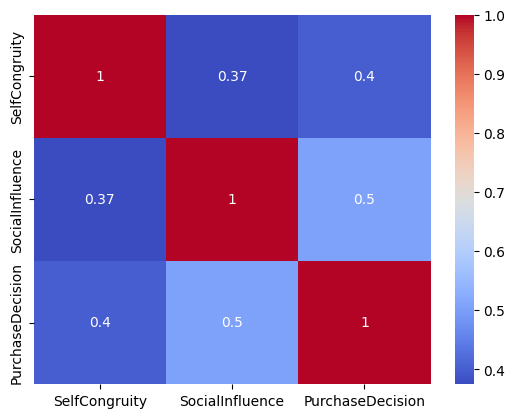

In [33]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()

# **Multiple Regression**

In [34]:
X = analysis[['SelfCongruity','SocialInfluence']]

Y = analysis['PurchaseDecision']

X = sm.add_constant(X)

model = sm.OLS(Y,X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       PurchaseDecision   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     32.77
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           1.65e-12
Time:                        17:02:07   Log-Likelihood:                -140.24
No. Observations:                 151   AIC:                             286.5
Df Residuals:                     148   BIC:                             295.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.0830      0.240     

In [35]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

vif

,Variable,VIF
0,const,22.722507
1,SelfCongruity,1.163237
2,SocialInfluence,1.163237


VIF < 5 = ปกติ

In [36]:
cronbach_alpha_self_congruity = pg.cronbach_alpha(self_congruity)
cronbach_alpha_social_influence = pg.cronbach_alpha(social_influence)
cronbach_alpha_purchase_decision = pg.cronbach_alpha(purchase_decision)

cronbach_table = pd.DataFrame({
    'Variable': ['Self Congruity', 'Social Influence', 'Purchase Decision'],
    'Cronbach_Alpha': [cronbach_alpha_self_congruity[0], cronbach_alpha_social_influence[0], cronbach_alpha_purchase_decision[0]],
    'CI_95': [str(cronbach_alpha_self_congruity[1]), str(cronbach_alpha_social_influence[1]), str(cronbach_alpha_purchase_decision[1])]
})

item_total_self = item_total(self_congruity)
item_total_social = item_total(social_influence.dropna())
item_total_purchase = item_total(purchase_decision.dropna())

with pd.ExcelWriter('research_results.xlsx') as writer:

    # Demographic
    gender_table.to_excel(writer, sheet_name='Gender')
    age_table.to_excel(writer, sheet_name='Age')
    year_table.to_excel(writer, sheet_name='Year')

    # Descriptive
    desc.to_excel(writer, sheet_name='Descriptive')

    # Mean
    dimension_mean.to_excel(writer, sheet_name='Dimension_Mean')

    # Cronbach
    cronbach_table.to_excel(writer, sheet_name='Cronbach_Alpha')

    # Item-total
    item_total_self.to_excel(writer, sheet_name='ItemTotal_SelfCongruity')
    item_total_social.to_excel(writer, sheet_name='ItemTotal_SocialInfluence')
    item_total_purchase.to_excel(writer, sheet_name='ItemTotal_PurchaseDecision')

    # Correlation
    corr.to_excel(writer, sheet_name='Correlation')

    # VIF
    vif.to_excel(writer, sheet_name='VIF')

In [37]:
from google.colab import files

files.download("research_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>